Total sources: 5,263,013
After base cuts: 132,955
Selected by color-color box: 2,028


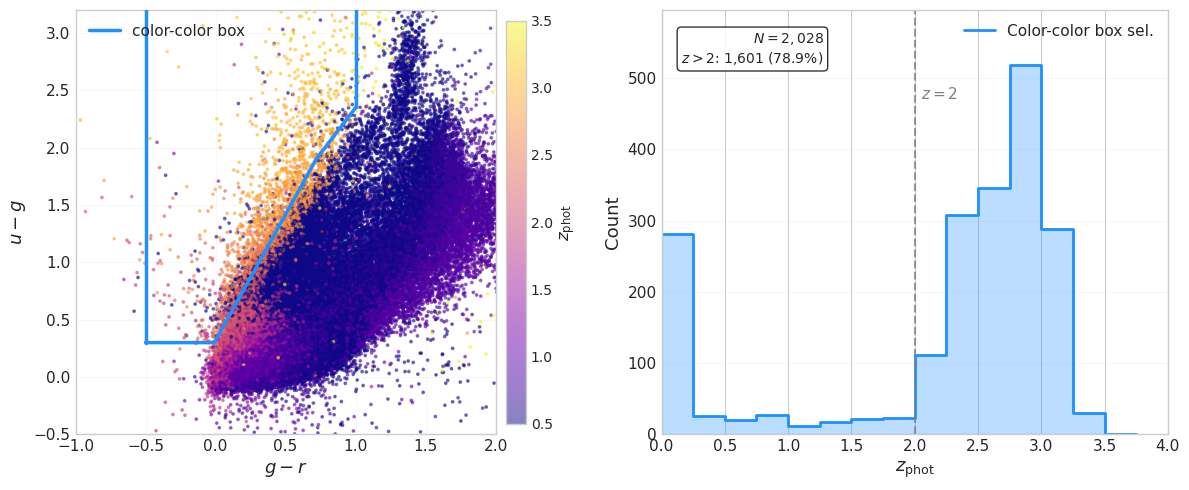

✓ Figure saved: ../images/cosmos_lbg_color_selection.png


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.table import Table

# =============================================================================
# Load COSMOS catalog
# =============================================================================
path_cosmos = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab = Table.read(path_cosmos, hdu=1)

# Extract columns
g = np.array(tab['g'], dtype=float)
r = np.array(tab['r'], dtype=float)
u = np.array(tab['u'], dtype=float)
u_err = np.array(tab['u_err'], dtype=float)
zphot = np.array(tab['ZPHOT'], dtype=float)
z_best = np.array(tab['Z_BEST'], dtype=float)
mask_flag = np.array(tab['MASK'])
flag_field = np.array(tab['FLAG_FIELD_BINARY'])
obj_type = np.array(tab['OBJ_TYPE'])

# Compute colors
g_r = g - r
u_g = u - g

# =============================================================================
# Selection criteria (common)
# =============================================================================
# Base selection: r-band cut, u_err cut, valid photometry, field flags
mask_base = (
    np.isfinite(g_r) & np.isfinite(u_g) &
    np.isfinite(zphot) & (zphot != -99) &
    np.isfinite(z_best) & (z_best != -99) &
    (r > 22.5) & (r < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

# Color-color box selection (u-dropout criteria)
cond_ug = u_g > 0.3
cond_gr = (g_r > -0.5) & (g_r < 1.0)
cond_diag = (u_g > (2.2*g_r + 0.32)) | ((u_g > (1.6*g_r + 0.75)) & (u_g > 0.9))

mask_box = mask_base & cond_ug & cond_gr & cond_diag

# Extract selected data
g_r_sel = g_r[mask_base]
u_g_sel = u_g[mask_base]
zphot_sel = zphot[mask_base]
z_box = zphot[mask_box]

print(f"Total sources: {len(tab):,}")
print(f"After base cuts: {mask_base.sum():,}")
print(f"Selected by color-color box: {mask_box. sum():,}")

# =============================================================================
# Compute color-cut boundary
# =============================================================================
g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([
    max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75)))
    for gr in g_r_line
])

# =============================================================================
# Create publication-quality figure (two panels, side by side)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# Left panel: Color-color diagram
# -----------------------------------------------------------------------------
ax1 = axes[0]

# Scatter plot with photo-z coloring
cmap = 'plasma'
norm = colors.Normalize(vmin=0.5, vmax=3.5)
sc = ax1.scatter(
    g_r_sel, u_g_sel, c=zphot_sel,
    cmap=cmap, norm=norm,
    s=3, alpha=0.5, rasterized=True
)

# Colorbar
cbar = fig.colorbar(sc, ax=ax1, pad=0.02, shrink=0.95)
cbar.set_label(r'$z_{\rm phot}$', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Color-cut boundary (blue polygon)
ax1.plot(g_r_line, lower_bound, color='dodgerblue', lw=2.5, 
         label='color-color box', zorder=5)
ax1.plot([-0.5, -0.5], [lower_bound[0], 3.5], color='dodgerblue', lw=2.5, zorder=5)
ax1.plot([1.0, 1.0], [lower_bound[-1], 3.5], color='dodgerblue', lw=2.5, zorder=5)
ax1.plot([-0.5, 1.0], [3.5, 3.5], color='dodgerblue', lw=2.5, zorder=5)

# Axis settings
ax1.set_xlim(-1.0, 2.0)
ax1.set_ylim(-0.5, 3.2)
ax1.set_xlabel(r'$g - r$', fontsize=13)
ax1.set_ylabel(r'$u - g$', fontsize=13)
ax1.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.5)
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# -----------------------------------------------------------------------------
# Right panel: Photo-z histogram of selected LBGs
# -----------------------------------------------------------------------------
ax2 = axes[1]

# Histogram settings
bins = np.arange(0, 4.25, 0.25)  # 0 to 4, step 0.25
counts, bin_edges = np.histogram(z_box, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Step histogram
ax2.step(bin_edges[:-1], counts, where='post', color='dodgerblue', lw=2, 
         label='Color-color box sel.')
ax2.fill_between(bin_edges[:-1], counts, step='post', alpha=0.3, color='dodgerblue')

# Reference line at z = 2 (LBG threshold)
ax2.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax2.text(2.05, ax2.get_ylim()[1]*0.9 if counts.max() > 0 else 10, 
         r'$z=2$', fontsize=11, color='gray', va='top')

# Axis settings
ax2.set_xlim(0, 4.0)
ax2.set_ylim(0, counts.max() * 1.15 if counts.max() > 0 else 10)
ax2.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax2.set_ylabel('Count', fontsize=13)
ax2.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')

# Statistics annotation
n_total = mask_box.sum()
n_z_gt_2 = np.sum(z_box > 2)
frac_z_gt_2 = n_z_gt_2 / n_total * 100 if n_total > 0 else 0
stats_text = (f'$N = {n_total:,}$\n'
              f'$z > 2$: {n_z_gt_2:,} ({frac_z_gt_2:.1f}%)')
ax2.text(0.32, 0.95, stats_text, transform=ax2.transAxes, fontsize=10,
         va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# -----------------------------------------------------------------------------
# Final layout
# -----------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('../images/cosmos_lbg_color_selection.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: ../images/cosmos_lbg_color_selection.png")